## Set-up

In [1]:
# @title
!pip install -q rdkit openbabel-wheel dockstring ollama oddt pubchempy py3Dmol

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 60.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 5.3 MB/s eta 0:00:00


In [2]:
# @title
!git clone https://github.com/MauricioCafiero/MolecularPropertyOptimization.git

Cloning into 'MolecularPropertyOptimization'...
remote: Enumerating objects: 1096, done.
remote: Counting objects: 100% (588/588), done.
remote: Compressing objects: 100% (460/460), done.
remote: Total 1096 (delta 236), reused 471 (delta 126), pack-reused 508 (from 1)
Receiving objects: 100% (1096/1096), 37.03 MiB | 40.42 MiB/s, done.
Resolving deltas: 100% (431/431), done.


In [3]:
# @title
import gradio as gr
import os
from PIL import Image
from collections import Counter
from typing import Annotated, TypedDict
import time, sys, re
from ollama import Client as ollama_client
from google.colab import userdata
import py3Dmol
from rdkit import Chem
from rdkit.Chem import Draw

sys.path.append('MolecularPropertyOptimization/code')
from MolPropOp import *
from docking_module import *

smiles_pattern = r'[CHONFClBrISPKacnosp0-9@+\-\[\]\(\)\/.=#$%]{5,}'

In [ ]:
# @title
# ## reload the MolPropOp library
# import importlib
# importlib.reload(sys.modules['MolPropOp'])
# from MolPropOp import *

## Code for Agent

In [4]:
# @title
ollama_key = userdata.get('ollama_key')
models = ['deepseek-v3.1:671b', 'gpt-oss:120b', 'gpt-oss:20b',
          'devstral-2:123b', 'cogito-2.1:671b',
          'nemotron-3-nano:30b', 'gemini-3-flash-preview',
          'kimi-k2:1t', 'kimi-k2.5', 'deepseek-v3.2']

model = models[-2]
if model == 'deepseek-v3.1:671b' or model == 'deepseek-v3.2':
  think_bool = False
else:
  think_bool = True


#get the number of cpu cores available
num_cores = os.cpu_count()

scoring_args[0] = num_cores
scoring_args[1] = 'HMGCR'

sys_message = f'''
# You are a cholesterol drug design assistant. The use will prompt you abput a drug design task and you will use the tools to answer the query.
Your criteria for a good cholesterol drug will be that it docks strongly in the HMGCR protein. Use no more than
10 tool calls for any given question.

## For reference the SMILES strings for several HMGCR inhibitors (cholesterol drugs) are:
- Atorvastatin,O=C(O)C[C@H](O)C[C@H](O)CCn2c(c(c(c2c1ccc(F)cc1)c3ccccc3)C(=O)Nc4ccccc4)C(C)C
- Rosuvastatin,OC(=O)C[C@H](O)C[C@H](O)\C=C\c1c(C(C)C)nc(N(C)S(=O)(=O)C)nc1c2ccc(F)cc2
- Simvastatin,O=C(O[C@@H]1[C@H]3C(=C/[C@H](C)C1)\C=C/[C@@H]([C@@H]3CC[C@H]2OC(=O)C[C@H](O)C2)C)C(C)(C)CC
- Lovastatin,O=C(O[C@@H]1[C@H]3C(=C/[C@H](C)C1)\C=C/[C@@H]([C@@H]3CC[C@H]2OC(=O)C[C@H](O)C2)C)[C@@H](C)CC
- Fluvastatin,O=C(O)C[C@H](O)C[C@H](O)/C=C/c2c(c1ccccc1n2C(C)C)c3ccc(F)cc3
- Pravastatin,O=C(O)C[C@H](O)C[C@H](O)CC[C@H]2[C@H](/C=C\C1=C\[C@@H](O)C[C@H](OC(=O)[C@@H](C)CC)[C@@H]12)C

- related: this tool generates a list of molecules that are structurally related to a given molecule, and
           may be useful for exploring the chemical space around promising molecules you find in the input
           data. It returns a list of related molecules and a few properties.

- lipinski: this tool evaluates a list of molecules for their drug-likeness based on Lipinski's rule of five,
            which is a set of guidelines for determining whether a molecule is likely to be an orally active
            drug in humans. This tool can help you ensure that the molecules you are proposing not only have
            good docking scores but also have properties that make them more likely to be successful as drugs.
            QED (quantitative estimate of drug-likeness) is a score between 0 and 1 that summarizes how
            drug-like a molecule is, with 1 being the most drug-like. A higher QED score indicates that a
            molecule has properties that are more consistent with known drugs, such as appropriate molecular
            weight, lipophilicity, and number of hydrogen bond donors and acceptors.

- calculate_SAS_and_NP(smiles_list: list[str]) -> str: Calculates the SAS and NP scores for a list of SMILES strings.
            SAS score is a measure of synthetic accessibility, and a value of 1 indicates that the molecule is easy to synthesize,
            while a value of 10 indicates that it is difficult to synthesize. NP score is a measure of natural product-likeness,
            and a higher score indicates that the molecule is more similar to natural products; the score runs from -5 to 5, with higher scores
            indicating greater similarity to natural products. Should be called for promising molecules with good docking scores and
            good Lipinski Properties.

- dock_and_get_interacting_residues(smiles: str) -> str: Returns the docking score in HMGCR and types of interactions between a docked molecule and
            residues in HMGCR. To be used to evaluate whether or not a promising molecule is docked to the expected binding site.
            For the system studied here, HMGCR, the interactions for the known binder Rosuvastatin are:
## Contacts between the ligand and proteins residues -------------------------
- HBONDS interactions:
Atom O-25 forms a hbonds with GLU119
Atom O-25 forms a hbonds with GLU119
Atom O-28 forms a hbonds with ALA311
Atom O-28 forms a hbonds with ASP671
Atom F-14 forms a hbonds with ARG571
Atom F-14 forms a hbonds with SER642
Atom O-25 forms a hbonds with GLU119
Atom O-25 forms a hbonds with ASN315
Atom O-25 forms a hbonds with LYS672
Atom O-28 forms a hbonds with LYS673
Atom O-31 forms a hbonds with LYS295
HYDROPHOBIC_CONTACTS interactions:
Atom C-20 forms a hydrophobic_contacts with GLU119
Atom C-21 forms a hydrophobic_contacts with LEU122
Atom C-26 forms a hydrophobic_contacts with HIS312
Atom C-0 forms a hydrophobic_contacts with LEU413
Atom C-9 forms a hydrophobic_contacts with LEU413
Atom C-9 forms a hydrophobic_contacts with LEU417
Atom C-10 forms a hydrophobic_contacts with LEU417
Atom C-10 forms a hydrophobic_contacts with VAL664
PI_STACKING interactions:

PI_CATION interactions:

HALOGENBONDS interactions:
Atom F-14 forms a halogenbonds with SER642
SALT_BRIDGES interactions:
Atom O-32 forms a salt_bridges with LYS295
Atom O-32 forms a salt_bridges with ARG571
Atom O-32 forms a salt_bridges with LYS673
List of all interacting residues:
 ALA311, ARG571, ASN315, ASP671, GLU119, HIS312, LEU122, LEU413, LEU417, LYS295, LYS672, LYS673, SER642, VAL664

## If you have identified good potential hit, evaluate the Lipinski properties of the proposed molecule
and use that information to further refine your proposals, keeping in mind that you want to propose molecules
that not only have good docking scores but also have good drug-like properties.
'''

global messages
messages = [{'role': 'system', 'content': sys_message}]

#@spaces.GPU
def start_chat():
  '''
  '''
  global chat_history, messages, reasoning
  chat_history = []
  reasoning = []
  messages = [{'role': 'system', 'content': sys_message}]

#@spaces.GPU
def chat_turn(prompt: str):
  '''
  '''
  global chat_history, messages, reasoning

  client = ollama_client(host = 'https://ollama.com',
            headers={'Authorization': f'Bearer {ollama_key}'})

  available_functions = {
    'related': related,
    'lipinski': lipinski,
    'dock_and_get_interacting_residues': dock_and_get_interacting_residues,
    'calculate_SAS_and_NP': calculate_SAS_and_NP,
  }

  messages.append({'role': 'user', 'content': prompt})

  while True:
      response = client.chat(
          model=model,
          messages=messages,
          tools=[grow_cycle, replace_groups, make_random_list, related, lipinski, dock_and_get_interacting_residues, calculate_SAS_and_NP],
          think=think_bool,
      )
      messages.append(response.message)
      print('------------------------------------------------------------------------')
      print("Thinking: ", response.message.thinking)
      print('------------------------------------------------------------------------')
      print("Content: ", response.message.content)
      print('------------------------------------------------------------------------')
      if response.message.tool_calls:
        for tc in response.message.tool_calls:
          if tc.function.name in available_functions:
            print(f"Calling {tc.function.name} with arguments {tc.function.arguments}")
            result = available_functions[tc.function.name](**tc.function.arguments)
            print(f"Result: {result}")
            print('------------------------------------------------------------------------')
            # add the tool result to the messages
            messages.append({'role': 'tool', 'tool_name': tc.function.name, 'content': str(result)})
      else:
        # end the loop when there are no more tool calls
        break

  return '', None, messages[-1]['content']

def show_protein():
  '''
  Show protein structure from PDB
  Input: PDB ID
  Output: structure view
  '''
  colors = ['turquoise', 'red', 'yelllow', 'blue', 'green', 'orange', 'purple']
  chains = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

  with open(f'MolecularPropertyOptimization/poses/HMGCR_dude_receptor.pdb', 'r') as f:
    pdb_str = f.read()

  with open('test_mol.sdf', 'r') as g:
    sdf_str = g.read()

  pdbview = py3Dmol.view(width=800, height=600)
  pdbview.addModel(pdb_str, 'pdb')


  for i, chain in enumerate(chains):
    try:
      pdbview.setStyle({'model': -1}, {'cartoon': {'ribbon': True, 'style': 'oval', 'color': 'spectrum'}})
    except:
      print('No additional chains')

  pdbview.addModel(sdf_str, 'sdf')
  pdbview.setStyle({'model': -1},{"stick": {}, "sphere": {"radius": 0.5}})

  pdbview.zoomTo()
  return pdbview

<>:102: SyntaxWarning: invalid escape sequence '\C'
<>:102: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_12198/2512558762.py:102: SyntaxWarning: invalid escape sequence '\C'
  '''


In [5]:
start_chat()

In [6]:
scoring_args[1] = 'HMGCR'
resp = dock_and_get_interacting_residues('c1ccccc1')

In [7]:
resp

'Docking score for the ligand: -3.8\n## Contacts between the ligand and proteins residues -------------------------\n\nHBONDS interactions:\n\n\nHYDROPHOBIC_CONTACTS interactions:\nAtom C-4 forms a hydrophobic_contacts with LEU122\nAtom C-0 forms a hydrophobic_contacts with THR318\nAtom C-5 forms a hydrophobic_contacts with THR318\nAtom C-5 forms a hydrophobic_contacts with ALA319\n\n\nPI_STACKING interactions:\n\n\nPI_CATION interactions:\n\n\nHALOGENBONDS interactions:\n\n\nSALT_BRIDGES interactions:\nList of all interacting residues:\n ALA319, LEU122, THR318'

# AI Agents for Drug Design 💊🔬✨

## The Problem: Design novel drugs to help fight high cholesterol! 🎯💔

## The How: Drug molecules that fit into a protein called HMG Coenzyme A Reductase. They stop your body's natural production of cholesterol. 🧩💪

## The AI: We provide an AI with drug design tools that allow it to test its hypotheses, refine its ideas, and come up with realistic solutions! 🤖💡
- A tool to check how a molecule fits into the protein 🧐🔬
- A tool to check if the molecule can be absorbed by your body 💧📊
- A tool to look for other molecules that are similar to a specific molecule 🕵️‍♀️🧪
- A tool to check how easy it is to actually make a molecule in the lab. 🏗️✨

## Examples of current cholesterol drugs: 🧪💊

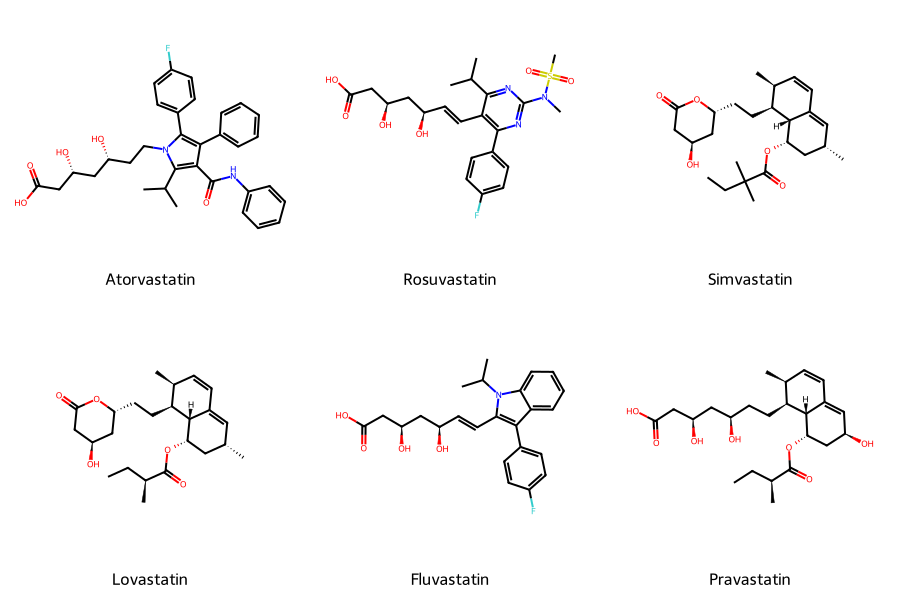

In [9]:
# @title
statins = [
('Atorvastatin',r'O=C(O)C[C@H](O)C[C@H](O)CCn2c(c(c(c2c1ccc(F)cc1)c3ccccc3)C(=O)Nc4ccccc4)C(C)C'),
('Rosuvastatin',r'OC(=O)C[C@H](O)C[C@H](O)\C=C\c1c(C(C)C)nc(N(C)S(=O)(=O)C)nc1c2ccc(F)cc2'),
('Simvastatin',r'O=C(O[C@@H]1[C@H]3C(=C/[C@H](C)C1)\C=C/[C@@H]([C@@H]3CC[C@H]2OC(=O)C[C@H](O)C2)C)C(C)(C)CC'),
('Lovastatin',r'O=C(O[C@@H]1[C@H]3C(=C/[C@H](C)C1)\C=C/[C@@H]([C@@H]3CC[C@H]2OC(=O)C[C@H](O)C2)C)[C@@H](C)CC'),
('Fluvastatin',r'O=C(O)C[C@H](O)C[C@H](O)/C=C/c2c(c1ccccc1n2C(C)C)c3ccc(F)cc3'),
('Pravastatin',r'O=C(O)C[C@H](O)C[C@H](O)CC[C@H]2[C@H](/C=C\C1=C\[C@@H](O)C[C@H](OC(=O)[C@@H](C)CC)[C@@H]12)C')
]

mols = [Chem.MolFromSmiles(mol) for _, mol in statins]
legends = [name for name, _ in statins]
Draw.MolsToGridImage(mols, legends=legends, molsPerRow=3, subImgSize=(300,300))


In [10]:
#@title ## Chat with the AI Agent:
your_question = "Propose a new drug for Cholesterol" #@param {type:"string"}
chat_turn(your_question)
show_protein()

------------------------------------------------------------------------
Thinking:  The user wants me to propose a new drug for cholesterol. I should start by examining the known HMGCR inhibitors (statins) provided in the context to understand their structure and then use the tools to generate new candidate molecules.

Let me first dock one of the known drugs to establish a baseline for what a good docking score looks like, and then I can use that information to guide the design of new molecules.

Let me start by docking Rosuvastatin, which is mentioned as a known binder with detailed interaction information provided.
------------------------------------------------------------------------
Content:  I'll help you propose a new cholesterol drug targeting HMGCR. Let me start by evaluating one of the known statins to establish a baseline, then use that information to design new candidates.
------------------------------------------------------------------------
Calling dock_and_get_intera

3Dmol.js failed to load for some reason. Please check your browser console for error messages.